# Python simulation of Free fall experiment:

In [1]:
#Free Fall Gravity Equation:

import sympy as sy
d , t =sy.symbols("d t")
g=2*d/t**2
print("Free Fall Gravity Equation:")
g

Free Fall Gravity Equation:


2*d/t**2

In [132]:
#Creating a Table1 and performing calculations on it

import pandas as pd

D=11.95
rmm=D/2
rm=rmm/1000

data={'D(mm)':[D],'r(mm)':[rmm],'r(m)':[rm]}

df=pd.DataFrame(data)

df=df.style.set_table_styles([{'selector':'thead th','props':[('background-color','teal'),('color', 'white')]}])

df

,D(mm),r(mm),r(m)
0,11.950000,5.975000,0.005975


In [142]:
#Creating a Table2 and performing calculations on it

import pandas as pd

data={'h(cm)':[70,60,50,40,30],'T1(msec)':[374.45,345.07,316.01,277.88,234.34],'T2(msec)':[376.64,346.7,316.92,287.74,231.68]}

df=pd.DataFrame(data)

df['h(m)']=df['h(cm)']/100
df['H-r(m)']=df['h(m)']-rm
df['T-AVG(mes)']=(df['T1(msec)']+df['T2(msec)'])/ 2
df['T(sec)']=df['T-AVG(mes)']/1000
df['T² (sec²)']=df['T(sec)']**2

order=['h(cm)','h(m)','H-r(m)','T1(msec)','T2(msec)','T-AVG(mes)','T(sec)','T² (sec²)']

df=df[order]

df=df.style.set_table_styles([{'selector':'thead th','props':[('background-color','teal'),('color','white')]}]).format(precision=3)

df

,h(cm),h(m),H-r(m),T1(msec),T2(msec),T-AVG(mes),T(sec),T² (sec²)
0,70,0.700,0.694,374.450,376.640,375.545,0.376,0.141
1,60,0.600,0.594,345.070,346.700,345.885,0.346,0.120
2,50,0.500,0.494,316.010,316.920,316.465,0.316,0.100
3,40,0.400,0.394,277.880,287.740,282.810,0.283,0.080
4,30,0.300,0.294,234.340,231.680,233.010,0.233,0.054


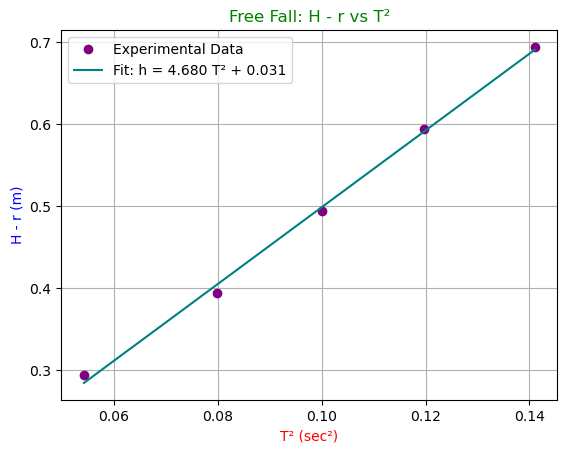

In [136]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

#extract values from the data frame

x = df.data['T² (sec²)'].values.reshape(-1, 1)
y = df.data['H-r(m)'].values

model = LinearRegression()
model.fit(x, y)

slope = model.coef_[0]
intercept = model.intercept_

plt.plot(x, y, 'o', label="Experimental Data", color="purple")
plt.plot(x, model.predict(x), label=f"Fit: h = {slope:.3f} T² + {intercept:.3f}", color="teal")

plt.xlabel("T² (sec²)", color="red")
plt.ylabel("H - r (m)", color="blue")
plt.title("Free Fall: H - r vs T²", color="green")

plt.legend()
plt.grid(True)
plt.show()

In [5]:
#Slop of h-r & t^2:

import sympy as sy
from sympy import Eq
h, r , T =sy.symbols("h r T")
Δy , Δx = sy.symbols("Δy Δx")

slop_form=Δy/Δx
slop=(h-r)/T**2
eq= Eq(slop_form,slop)

print("Slop:")
display(eq)

Slop:


Eq(Δy/Δx, (h - r)/T**2)

In [77]:
#Slope

import numpy as np

slope = (np.max(y) - np.min(y)) / (np.max(x) - np.min(x))
print("Slope:", slope,'m/s^2')

Slope: 4.611462021098197 m/s^2


In [7]:
# calculate the Gravity Acceleration:

import sympy as sy
slope2=sy.symbols("*slope")
print("Gravity Acceleration:")
2 * slope2

Gravity Acceleration:


2**slope

In [99]:
gravity=2 * slope
print('The gravity acceleration =',round(gravity,2),'m/s^2')

The gravity acceleration = 9.22 m/s^2


In [11]:
import sympy as sy
accu=sy.symbols("*smallestvalue")
print("Lab errors:")
0.5 * accu

Lab errors:


0.5**smallestvalue

In [85]:
#Accuracy

Ruler=float(input('The smallest value for Ruler:'))
Micrometer=float(input('The smallest value for Micrometer:'))
Timer=float(input('The smallest value for Timer:'))

print('Ruler:',0.5*Ruler,'cm')
print('Micrometer:',0.5*Micrometer,'mm')
print('Timer:',0.5*Timer,'msec')

The smallest value for Ruler: 0.1
The smallest value for Micrometer: 0.01
The smallest value for Timer: 0.01


Ruler: 0.05 cm
Micrometer: 0.005 mm
Timer: 0.005 msec


In [87]:
#Percentage Error:

import sympy as sy
theo , exp =sy.symbols("theo exp")
PE=(theo - exp)/theo
print("Percentage Error:")
sy.Abs(PE)*100

Percentage Error:


100*Abs((exp - theo)/theo)

In [117]:
#Percentage Error:

print('The Percentage Error =' ,abs(((gravity-9.81)/9.81)*100),'%')

The Percentage Error = 5.984464401667744 %


In [174]:
# Sorting the data to observe the relationship between T² and displacement
sorted_df = df.sort_values(by='T² (sec²)').reset_index(drop=True)

# Calculating the correlation coefficient between T² and H - r
correlation = sorted_df['T² (sec²)'].corr(sorted_df['H-r(m)'])

# Displaying the sorted data and correlation
print("Sorted Data:")
print(sorted_df)
print(f"\nCorrelation between T² and H - r : {correlation:.4f}")
print ('''

The sorted data and graph both demonstrate a strong linear relationship between
time squared (T²) and displacement (H - r), aligning with the theoretical equation :
h = 0.5 * g * t² 


This direct proportionality confirms that the object experiences constant
acceleration due to gravity, which validates the accuracy of our simulation 

The correlation coefficient obtained is very close to 1, indicating that
the data closely follows a linear trend as predicted 

This supports the objectives of the experiment :
- Simulated free fall motion using Python
- Visualized the relationship between time and displacement
- Compared simulated results with theoretical expectations
''')

Sorted Data:
   T² (sec²)  H-r(m)
0   0.053859  0.1882
1   0.077223  0.2882
2   0.100356  0.3882
3   0.119077  0.4882
4   0.134781  0.5882

Correlation between T² and H - r : 0.9965


The sorted data and graph both demonstrate a strong linear relationship between
time squared (T²) and displacement (H - r), aligning with the theoretical equation :
h = 0.5 * g * t² 


This direct proportionality confirms that the object experiences constant
acceleration due to gravity, which validates the accuracy of our simulation 

The correlation coefficient obtained is very close to 1, indicating that
the data closely follows a linear trend as predicted 

This supports the objectives of the experiment :
- Simulated free fall motion using Python
- Visualized the relationship between time and displacement
- Compared simulated results with theoretical expectations

